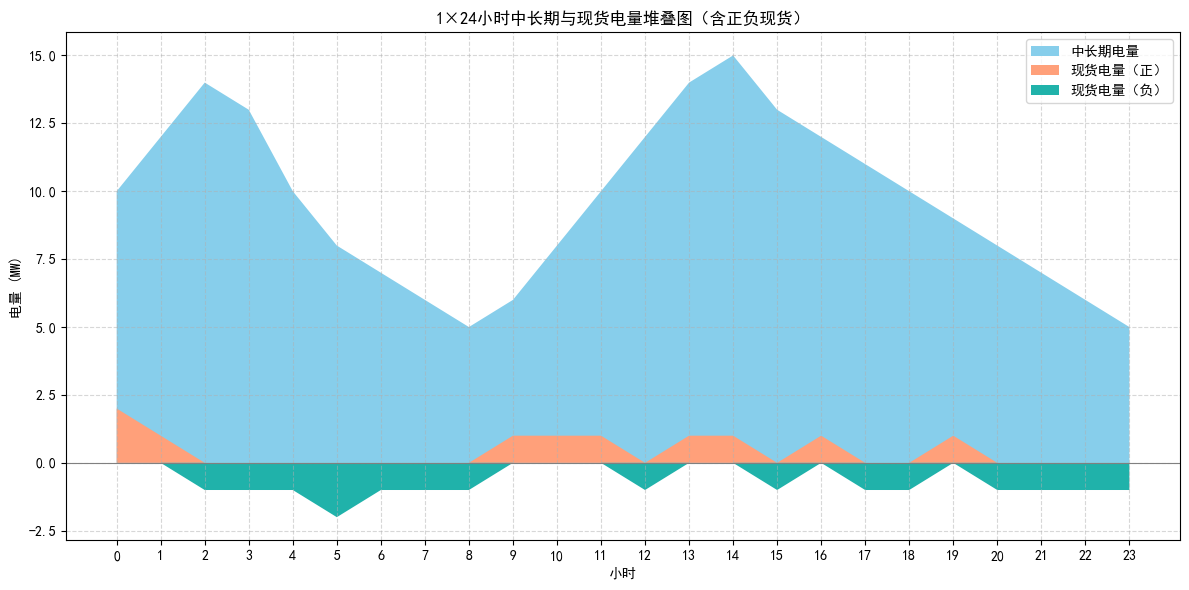

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# 示例数据（你可以替换成自己的）
data = {
    'hour': list(range(24)),
    'Q_contract': [10, 12, 14, 13, 10, 8, 7, 6, 5, 6, 8, 10, 12, 14, 15, 13, 12, 11, 10, 9, 8, 7, 6, 5],
    'Q_real':     [12, 13, 13, 12, 9, 6, 6, 5, 4, 7, 9, 11, 11, 15, 16, 12, 13, 10, 9, 10, 7, 6, 5, 4],
}
df = pd.DataFrame(data)
df['Q_spot'] = df['Q_real'] - df['Q_contract']
df['Q_spot_pos'] = df['Q_spot'].apply(lambda x: x if x > 0 else 0)
df['Q_spot_neg'] = df['Q_spot'].apply(lambda x: -x if x < 0 else 0)

# 绘图
plt.figure(figsize=(12, 6))

# 中长期电量
plt.stackplot(df['hour'], df['Q_contract'], labels=['中长期电量'], colors=['#87CEEB'])

# 正现货电量
plt.stackplot(df['hour'], df['Q_spot_pos'], labels=['现货电量（正）'], colors=['#FFA07A'], baseline='zero')

# 负现货电量（下凹，堆叠在反方向）
plt.stackplot(df['hour'], -df['Q_spot_neg'], labels=['现货电量（负）'], colors=['#20B2AA'], baseline='zero')

# 辅助设置
plt.axhline(0, color='gray', linewidth=0.8)
plt.xticks(range(0, 24))
plt.xlabel('小时')
plt.ylabel('电量 (MW)')
plt.title('1×24小时中长期与现货电量堆叠图（含正负现货）')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()
